### Step 0:  Data Collection

- https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009?resource=download

### EDA With Red Wine Data

Data Set Information:

The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine.  Due to privacy and logistic issues, only physicochemical (inputs) and sensory (the output) variables are available (e.g. there is no data about grape types, wine brand, wine selling price, etc.).

These datasets can be viewed as classification or regression tasks. The classes are ordered and not balanced (e.g. there are many more normal wines than excellent or poor ones). Outlier detection algorithms could be used to detect the few excellent or poor wines. Also, we are not sure if all input variables are relevant. So it could be interesting to test feature selection methods.


Attribute Information:

Input variables (based on physicochemical tests):
- 1 - fixed acidity
- 2 - volatile acidity
- 3 - citric acid
- 4 - residual sugar
- 5 - chlorides
- 6 - free sulfur dioxide
- 7 - total sulfur dioxide
- 8 - density
- 9 - pH
- 10 - sulphates
- 11 - alcohol

Output variable (based on sensory data):
- 12 - quality (score between 0 and 10)

#### Step 1: Import Required Library and Import Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

#### Import Data

In [3]:
df = pd.read_csv("Data/winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


#### Step 2: Basic Information

#### 1. Columns names

In [4]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

##### 2. Check duplicate rows 

In [5]:
df.duplicated().sum()

240

In [6]:
df[df.duplicated()]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.5,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1563,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1564,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1567,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1581,6.2,0.560,0.09,1.70,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5


##### 3. Check Numbers of Rows and Columns

In [7]:
print(f"Number of Rows     :- {df.shape[0]}")
print(f"Number of Columns  :- {df.shape[1]}")

Number of Rows     :- 1599
Number of Columns  :- 12


##### 4. Check for Null values

In [8]:
df.isnull().sum().sum()

0

##### 5. Check Data-Types of Columns

In [9]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

##### 6. Overall Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


#### 7. Column separation in Numerical and Category columns

In [11]:
df_num = df.select_dtypes('number')
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


#### Data Understanding

This DataSet contain **`1599 Rows`** and **`12 Columns`**

`Columns : 12`

**1. Numberical  Columns** :- 12 float64(11), int64(1)

**2. Categorical Columns** :- 0

The Dataset contains **`240 duplicate values`**

The Dataset contains **`No Missing Values.`**

#### Mathematical Summay

In [12]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


#### Step 3: Data Pre-Processing and Cleanning

In [13]:
# dropping duplicate values

df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

0

#### Step 4: EDA (Exploratory Data Analysis)
- Univariate (single variable)
- Bivariate (two variables), and 
- Multivariate (more than two variables)

#### Univariate 

In [15]:
df['quality'].value_counts()

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

<Axes: xlabel='quality', ylabel='Count'>

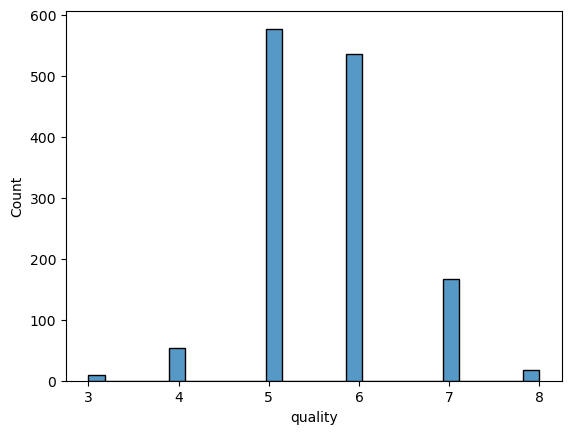

In [16]:
sns.histplot(x='quality',data=df)

This distribution suggests that most wines are rated average (quality 5 or 6), with very few considered excellent (8+) or poor (below 4). This insight can guide further analysis, like:

Investigating what features differentiate quality 6 wines from quality 7 or 8.

Balancing the dataset if used for classification tasks.

<Axes: xlabel='alcohol', ylabel='Count'>

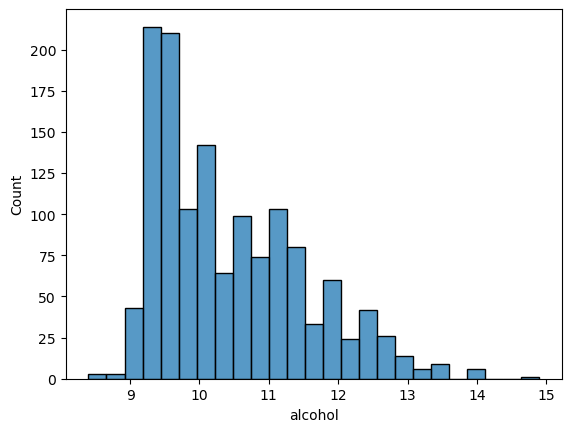

In [17]:
sns.histplot(x='alcohol',data=df,bins=25)

This histogram displays the distribution of alcohol content in the wine dataset. Most wines have an alcohol content between 9% and 11%, with the highest concentration around 9.2% to 9.4%. As alcohol content increases beyond 11%, the number of wines decreases steadily, indicating that higher alcohol wines are less common. The distribution is right-skewed, suggesting that while most wines are low to moderately alcoholic, a smaller portion has high alcohol levels. This pattern can be useful in understanding wine characteristics and may relate to quality, taste, or consumer preference.

### Data Correlation

In [18]:
df.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.255124,0.667437,0.111025,0.085886,-0.140580,-0.103777,0.670195,-0.686685,0.190269,-0.061596,0.119024
volatile acidity,-0.255124,1.000000,-0.551248,-0.002449,0.055154,-0.020945,0.071701,0.023943,0.247111,-0.256948,-0.197812,-0.395214
citric acid,0.667437,-0.551248,1.000000,0.143892,0.210195,-0.048004,0.047358,0.357962,-0.550310,0.326062,0.105108,0.228057
residual sugar,0.111025,-0.002449,0.143892,1.000000,0.026656,0.160527,0.201038,0.324522,-0.083143,-0.011837,0.063281,0.013640
chlorides,0.085886,0.055154,0.210195,0.026656,1.000000,0.000749,0.045773,0.193592,-0.270893,0.394557,-0.223824,-0.130988
free sulfur dioxide,-0.140580,-0.020945,-0.048004,0.160527,0.000749,1.000000,0.667246,-0.018071,0.056631,0.054126,-0.080125,-0.050463
total sulfur dioxide,-0.103777,0.071701,0.047358,0.201038,0.045773,0.667246,1.000000,0.078141,-0.079257,0.035291,-0.217829,-0.177855
density,0.670195,0.023943,0.357962,0.324522,0.193592,-0.018071,0.078141,1.000000,-0.355617,0.146036,-0.504995,-0.184252
pH,-0.686685,0.247111,-0.550310,-0.083143,-0.270893,0.056631,-0.079257,-0.355617,1.000000,-0.214134,0.213418,-0.055245
sulphates,0.190269,-0.256948,0.326062,-0.011837,0.394557,0.054126,0.035291,0.146036,-0.214134,1.000000,0.091621,0.248835


<Axes: >

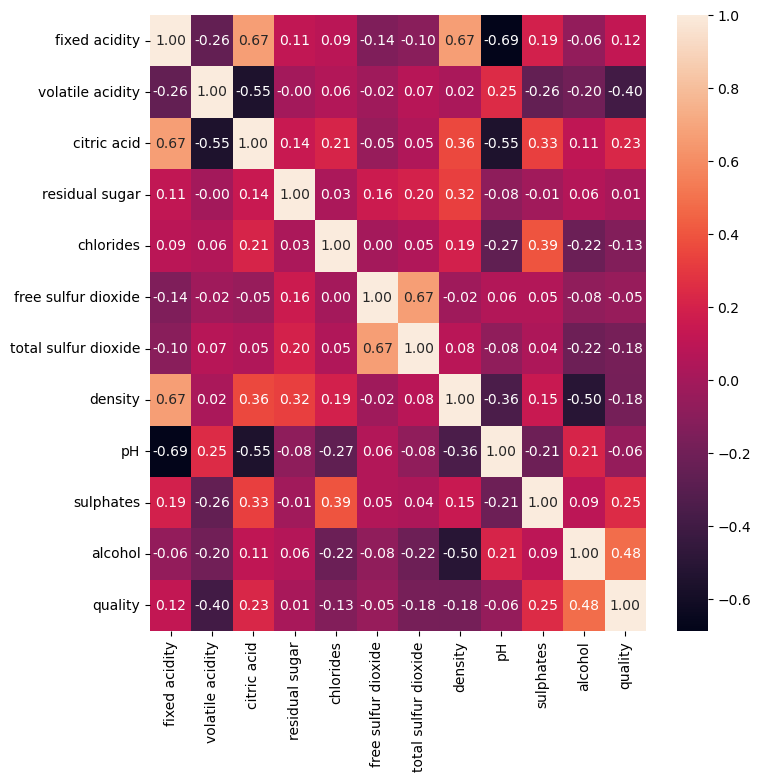

In [19]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(),annot=True,fmt='.2f')

### Bivariate 
- line
- bar
- scatter
- heatmap

### Alcohol vs Quality

<Axes: xlabel='quality', ylabel='alcohol'>

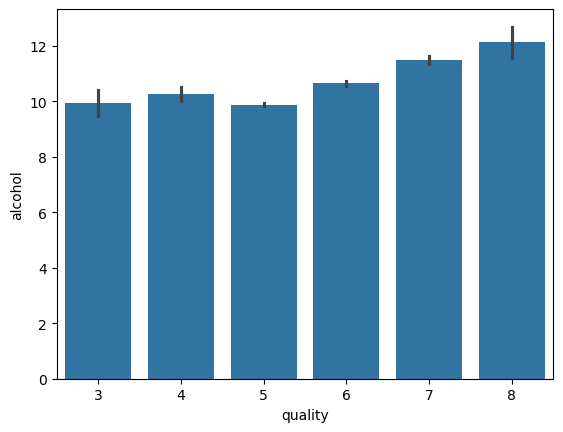

In [20]:
sns.barplot(x='quality' , y = 'alcohol' , data = df)

The bar chart displays the average alcohol content corresponding to different wine quality ratings. As the quality rating increases from 3 to 8, the average alcohol content generally rises. Wines with the lowest quality rating (3) have an average alcohol level close to 10%, while those rated highest (8) reach about 12%. This positive correlation suggests that higher quality wines tend to contain more alcohol. Error bars indicate the variability or standard error in each quality group, with wider bars at the extremes, especially for quality 3 and 8, implying greater variability in alcohol content within those groups compared to others.

In [21]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

### fixed acidity bs Quality

<Axes: xlabel='quality', ylabel='fixed acidity'>

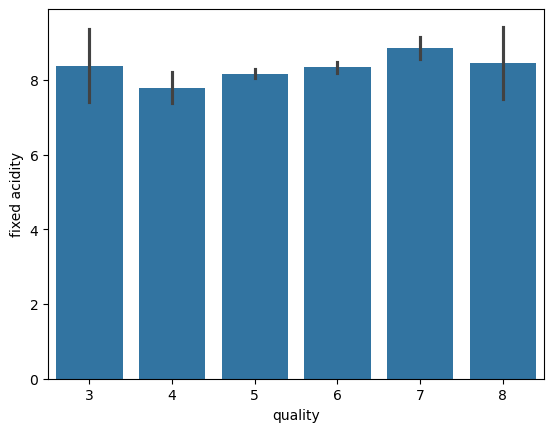

In [27]:
sns.barplot(x='quality' , y = 'fixed acidity' , data = df)

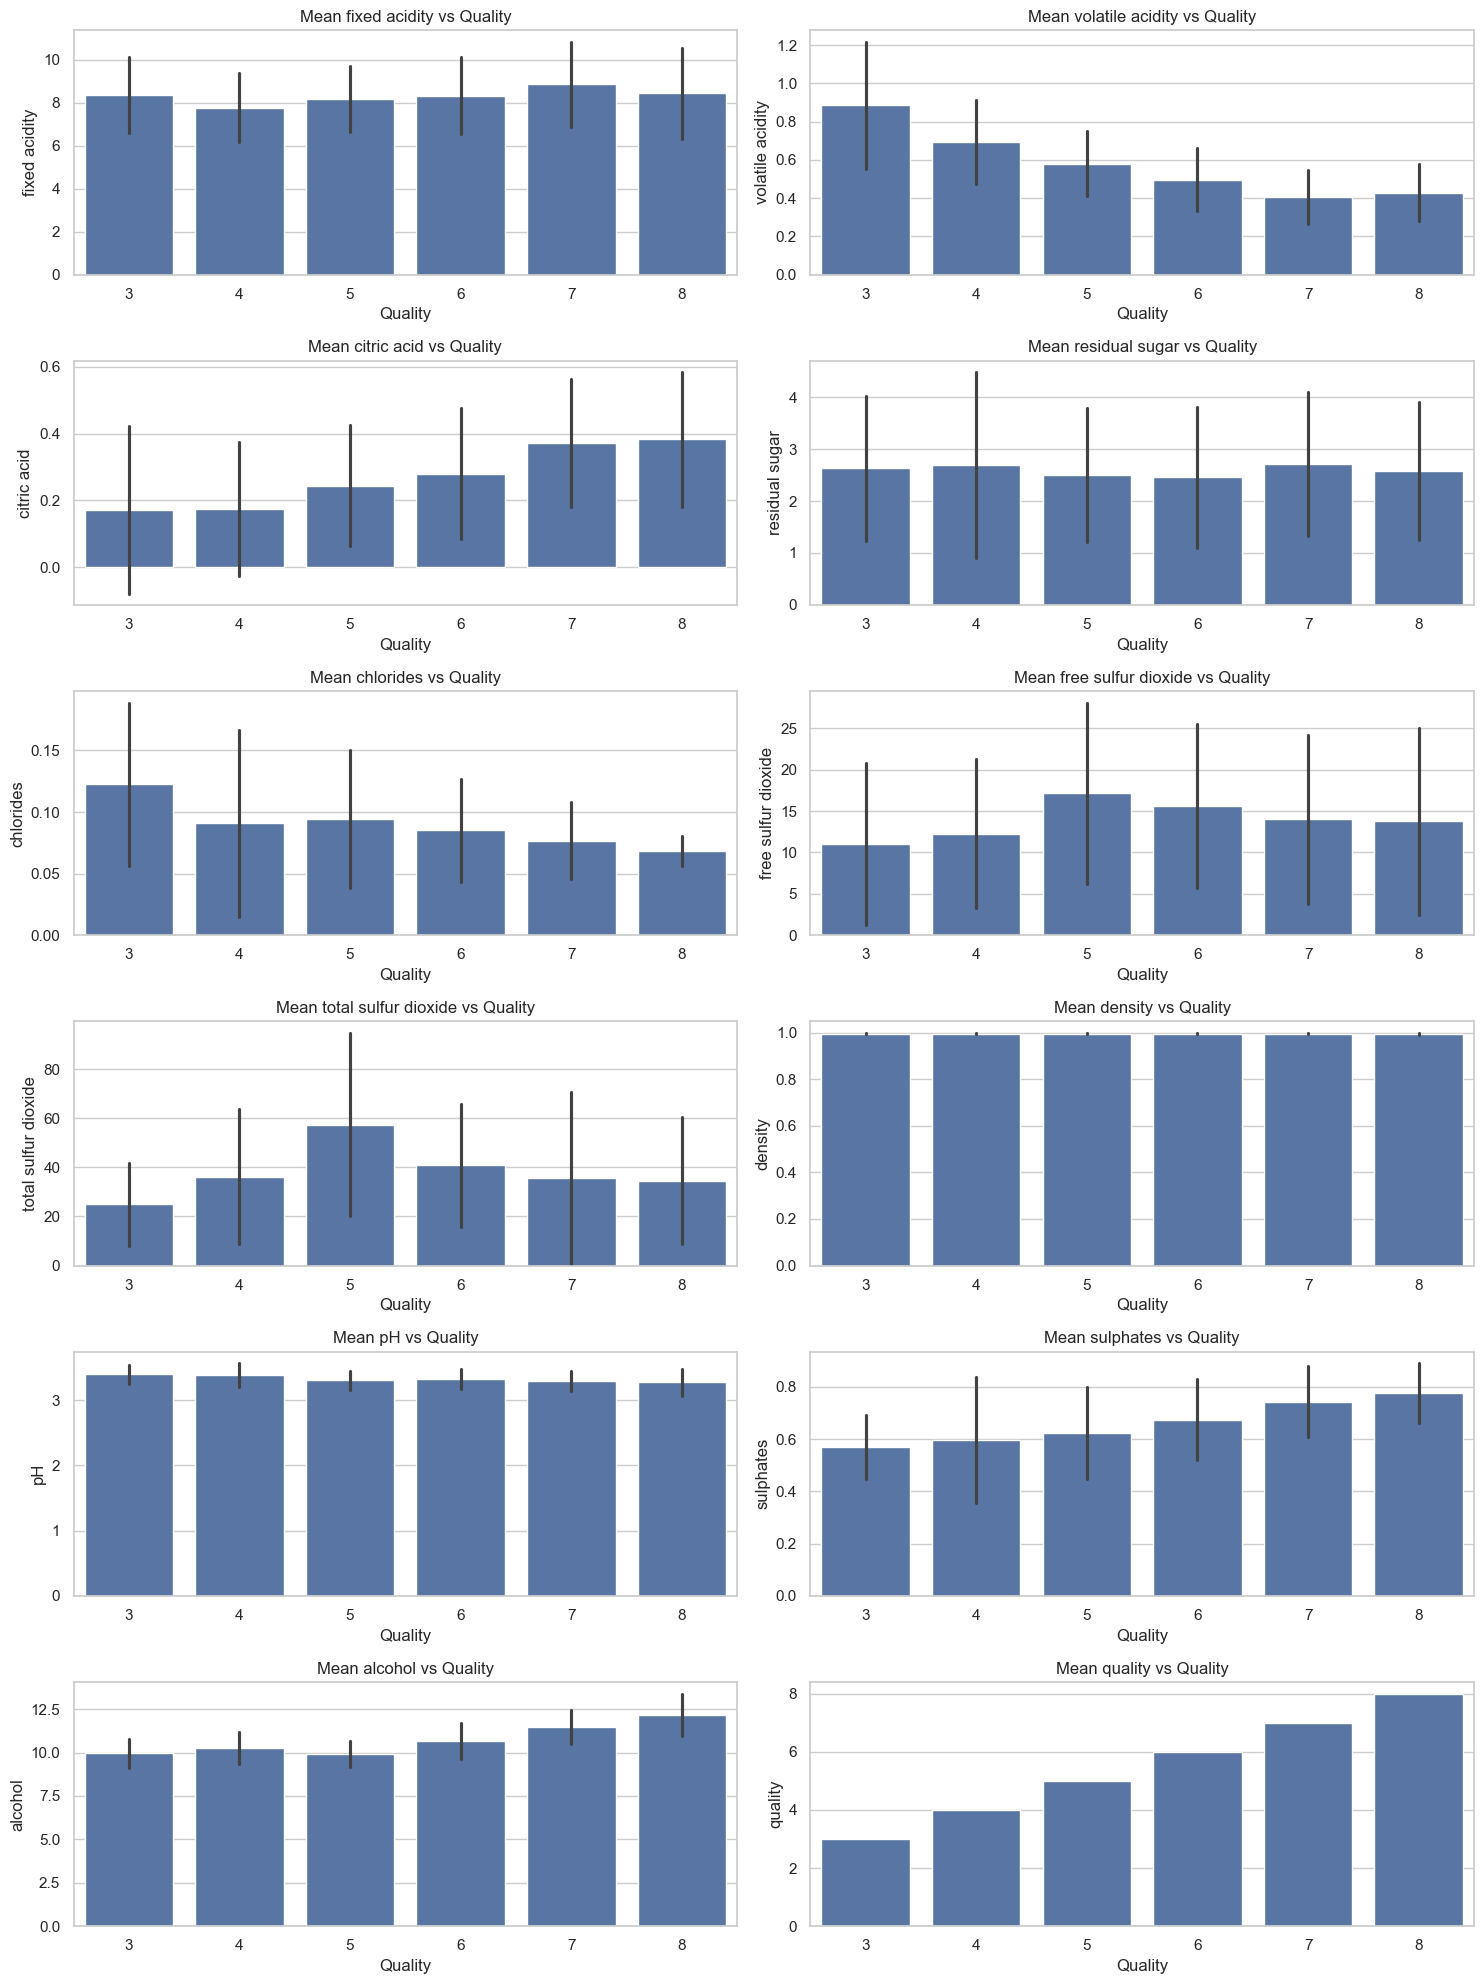

In [34]:
plt.figure(figsize=(15,20))

# Create bar plots
for i, col in enumerate(df.columns, 1):
    plt.subplot(6, 2, i)  # 6 rows, 2 columns layout
    sns.barplot(x='quality', y=col, data=df, ci='sd')
    plt.title(f'Mean {col} vs Quality')
    plt.xlabel('Quality')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### Multivariate

In [39]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [40]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


<Axes: xlabel='quality', ylabel='alcohol'>

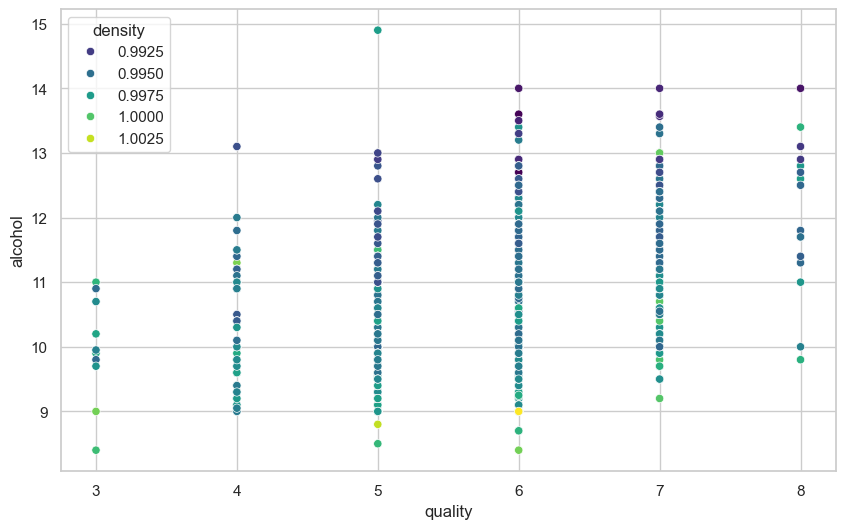

In [42]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='quality', y='alcohol', hue='density', data=df, palette='viridis')

The scatter plot visualizes the relationship between alcohol content and wine quality, with density represented by color. As quality increases from 3 to 8, alcohol levels generally tend to rise, suggesting that higher quality wines often have higher alcohol content. The color gradient (from dark purple to yellow-green) indicates density, with lower density wines (darker colors) more common at higher alcohol levels. Conversely, wines with higher densities (lighter colors) are clustered toward lower alcohol percentages and lower quality scores. This implies a potential inverse relationship between density and alcohol, and a positive association between alcohol content and perceived wine quality.

<Axes: xlabel='quality', ylabel='alcohol'>

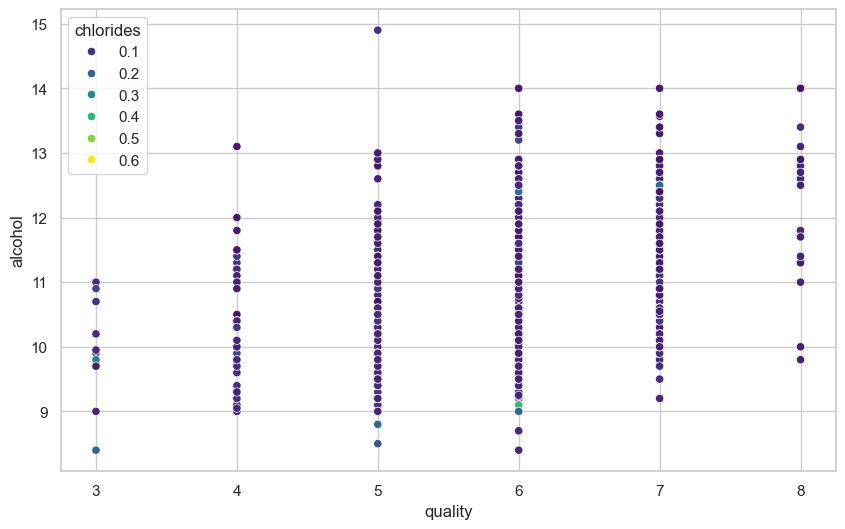

In [48]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='quality', y='alcohol', hue='chlorides', data=df, palette='viridis')

This scatter plot shows the relationship between alcohol content and wine quality, with chloride levels represented by color. Most points appear dark purple, indicating that the majority of wines have low chloride levels around 0.1. Higher chloride levels (yellow-green dots) are rare, and do not show any strong association with high quality or high alcohol content. Wines with better quality (quality score 6 to 8) generally have moderate to high alcohol content, but the chloride concentration seems to have little to no clear pattern with either alcohol or quality. Overall, chlorides do not appear to significantly influence wine quality in this dataset.

<Axes: xlabel='alcohol', ylabel='pH'>

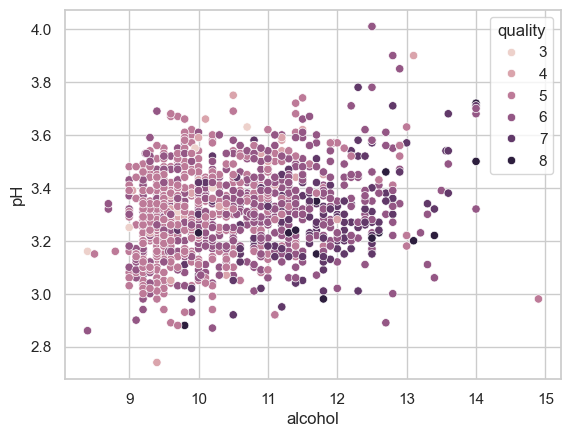

In [49]:
sns.scatterplot(x='alcohol',y='pH',hue='quality',data=df)

The scatter plot displays the relationship between alcohol content and pH levels in wine, with data points color-coded by quality rating (from 3 to 8). Most wines cluster between 9–13% alcohol and pH levels of 3.0–3.6. Higher quality wines (darker dots) tend to appear more frequently at higher alcohol levels, particularly above 11%, suggesting a positive correlation between alcohol content and quality. Conversely, lower-quality wines (lighter shades) are more prevalent in the lower alcohol range. The pH values show a less distinct pattern across quality levels, indicating alcohol content may be a stronger indicator of perceived wine quality in this dataset.

#### Conclusion :
The exploratory data analysis reveals several key insights into wine quality. Alcohol content shows the strongest positive correlation with wine quality (0.48), indicating that higher alcohol levels are generally associated with better-rated wines. Conversely, volatile acidity negatively correlates with quality (−0.40), suggesting that wines with higher acidity tend to receive lower ratings. Density and pH also show moderate relationships with alcohol and quality. Density decreases with increasing alcohol and quality, while pH tends to remain within a narrow range. Chlorides and sulphates have weaker relationships with quality. Overall, alcohol, acidity, and density are influential factors in determining wine quality.